In [3]:
import kwant
import numpy as np
import matplotlib.pyplot as plt

In [32]:
#参数
dela = 1
t = 38 * dela
af = 400/0.1875* dela * 10**(-10)
a = 10**(-10)#/(400/6)
mu = 8 * dela
U = 1.9 * dela
mz = 7 * dela
h = 1.2 * np.sqrt(mu**2 + dela**2)
#L = 11
chaodaojiao = 0
saimanjiao = 0
#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.eye(2, dtype=complex)

#左边矩阵信息
HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy
Delta_L=dela * np.exp(1j*chaodaojiao/2) * 1j * sy
H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])
H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sz/a)
H_L_right_to_left_hop=np.block([
        [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj() ]
    ])

#中间矩阵信息
H_center_to_L=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_center_block=(U-mu+2*t)*s0+mz*sz
H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])
    
H_center_right_to_left_hop=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_R_to_center=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])

#右边矩阵信息
HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy
Delta_R=dela * np.exp(-1j*chaodaojiao/2) * 1j * sy
H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
H_R_right_to_left_hop_block=-1*(t*s0+1j*af/a*sz)
H_R_right_to_left_hop=np.block([
        [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
    ])


In [35]:
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T
H_l= H_L_onsite
T_l= H_L_right_to_left_hop
H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T
T_LD=H_center_to_L
T_RD= H_R_to_center
N=10
q=2
def gr_L(A_l_wei, T_l_wei, tol=1, maxiter=1000):
    grl = np.linalg.inv(A_l_wei)
    for _ in range(maxiter):
        grl_new = np.linalg.inv(
            A_l_wei - T_l_wei.conj().T @ grl @ T_l_wei
        )
        err = np.linalg.norm(grl_new - grl, ord='fro') / np.linalg.norm(grl_new, ord='fro')
        if err < tol:
            return grl_new
        grl = grl_new
    raise RuntimeError("surface Green function did not converge")

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=1e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)

    A_l = (E + 1j*eta) * np.eye(H_l.shape[0]) - H_l               
    Sigma_L = zinengr_L(T_LD, gr_L(A_l, T_l) )     


    A_r = (E + 1j*eta) * np.eye(H_r.shape[0]) - H_r
    Sigma_R = zinengr_L(T_RD, gr_L(A_r, T_r))

    dim = N * d
    A_DD = np.zeros((dim, dim), dtype=complex)

    for i in range(N):
        if i == 0:
            Aii = E*I - H_q - Sigma_L
        elif i == N-1:
            Aii = E*I - H_q - Sigma_R
        else:
            Aii = E*I - H_q

        A_DD[i*d:(i+1)*d, i*d:(i+1)*d] = Aii

        if i < N-1:
            A_DD[i*d:(i+1)*d, (i+1)*d:(i+2)*d] = -T_12

        if i > 0:
            A_DD[i*d:(i+1)*d, (i-1)*d:i*d] = -T_12.conj().T

    G_DD_r = np.linalg.inv(A_DD)
    return G_DD_r , A_DD ,Sigma_R ,Sigma_L 


def G_DD_less_then(A_DD ,G_DD_r,zinengr_L_wei,zinengr_R_wei,E):  

    feimi1 = 1.0 / (8.617333262e-5 * 1e-6)
    feimi2 = 1.0 / (8.617333262e-5 * 1e-6)  
    zineng_DD_less_then = np.zeros((H_q.shape[0]*N, H_q.shape[0]*N), dtype=complex)
    zineng_DD_less_then[0:4, 0:4]=-(zinengr_L_wei - zinengr_L_wei.conj().T)*(1/(1+np.exp((E - mu) * feimi1)))
    zineng_DD_less_then[(N-1)*4:4*N, (N-1)*4:4*N]=-(zinengr_R_wei - zinengr_R_wei.conj().T)*(1/(1+np.exp((E - mu) * feimi2)))

    G_DD_less_then_wei= G_DD_r @ zineng_DD_less_then @ G_DD_r.conj().T 
    return G_DD_less_then_wei

#G_DD_r=Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=1e-6)[0]
def bufeng(G_DD_r):
    yigeshu=np.trace(G_DD_r)
    return -np.imag(yigeshu)/np.pi

def J_integral(G_DD_less_then_wei,T_12,q):
    d= T_12.shape[0]
    J=T_12 @ G_DD_less_then_wei[q*d:(q+1)*d, (q+1)*d:(q+2)*d]- T_12.conj() @ G_DD_less_then_wei[(q+1)*d:(q+2)*d, (q)*d:(q+1)*d]
    return np.real(np.trace(J))/(2*np.pi)

    
def current_from_ABS(E_set, q):
    I_total = 0.0

    for E in E_set:
        G_DD_r, A_DD, Sigma_R, Sigma_L = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )

        G_less = G_DD_less_then(A_DD, G_DD_r, Sigma_L, Sigma_R, E)
        I_E = J_integral(G_less, T_12, q)

        I_total += I_E

    return I_total




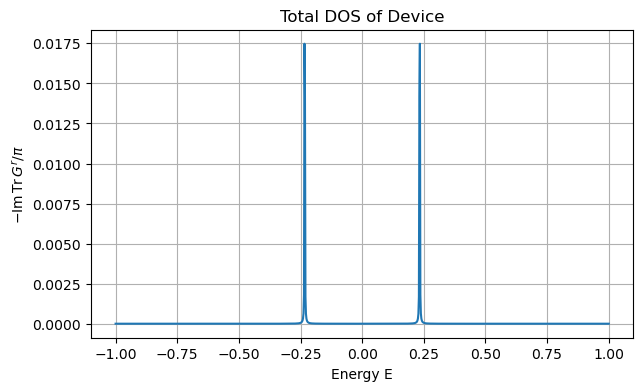

In [34]:
import matplotlib.pyplot as plt

def scan_bufeng(Emin=-100, Emax=100, nE=2001):

    Es = np.linspace(Emin, Emax, nE)
    rho = np.zeros_like(Es)

    for i, E in enumerate(Es):
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        rho[i] = bufeng(G_DD_r)

    return Es, rho


Es, rho = scan_bufeng(-1, 1, 1001)

plt.figure(figsize=(7,4))
plt.plot(Es, rho, lw=1.5)
plt.xlabel("Energy E")
plt.ylabel(r"$-\mathrm{Im}\,\mathrm{Tr}\,G^r/\pi$")
plt.title("Total DOS of Device")
plt.grid(True)
plt.show()


In [31]:
from scipy.signal import find_peaks

def find_E_set_from_bufeng(Emin=-100, Emax=100, nE=2001, prominence=0.1):

    Es = np.linspace(Emin, Emax, nE)
    rho = np.zeros_like(Es)

    # 扫描能量
    for i, E in enumerate(Es):
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        rho[i] = bufeng(G_DD_r)

    # 找峰
    peaks, _ = find_peaks(rho, prominence=prominence)


    E_set = Es[peaks]

    return E_set, Es, rho
E_set, Es, rho = find_E_set_from_bufeng(
    Emin=-1,
    Emax=1,
    nE=2000,
    prominence=0.01
)

print("E_set (ABS energies):")
print(E_set)


E_set (ABS energies):
[-0.22861431  0.22861431]
